In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import shap

import warnings
warnings.filterwarnings("ignore")  

# 1. Data Loading.

In [103]:
# Set the style of the plot
sns.set_style("whitegrid")

In [104]:
# Load data
data = pd.read_csv("data.csv")

In [105]:
# Rename columns
data.columns = ['customer_happiness', 'delivery_timeliness','order_accuracy','product_availability',
              'price_value_perception','courier_service_rating', 'app_usability']

In [106]:
# Basic overview of the data
data.head()

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [107]:
data.tail()

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5
125,0,5,3,2,5,5,5


In [108]:
data.info()
data.describe(include = 'all')

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   customer_happiness      126 non-null    int64
 1   delivery_timeliness     126 non-null    int64
 2   order_accuracy          126 non-null    int64
 3   product_availability    126 non-null    int64
 4   price_value_perception  126 non-null    int64
 5   courier_service_rating  126 non-null    int64
 6   app_usability           126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# 2. Data Quality Checks.

In [109]:
for column in data.columns:
    unique_values = data[column].value_counts()
    print(f"Unique values in '{column}': {unique_values}")

Unique values in 'customer_happiness': customer_happiness
1    69
0    57
Name: count, dtype: int64
Unique values in 'delivery_timeliness': delivery_timeliness
5    65
4    40
3    20
1     1
Name: count, dtype: int64
Unique values in 'order_accuracy': order_accuracy
3    42
2    34
1    27
4    17
5     6
Name: count, dtype: int64
Unique values in 'product_availability': product_availability
3    55
4    33
5    17
2    14
1     7
Name: count, dtype: int64
Unique values in 'price_value_perception': price_value_perception
4    53
3    41
5    25
2     5
1     2
Name: count, dtype: int64
Unique values in 'courier_service_rating': courier_service_rating
4    50
5    31
3    22
2    16
1     7
Name: count, dtype: int64
Unique values in 'app_usability': app_usability
5    57
4    47
3    20
2     1
1     1
Name: count, dtype: int64


## 2.1. Null check remove null rows.

In [110]:
# Count number of rows with null values
num_rows_with_nulls = data.isnull().any(axis=1).sum()
print(f"Number of rows with at least one null value: {num_rows_with_nulls}")

Number of rows with at least one null value: 0


In [111]:
# Drop rows with null values
data = data.dropna()

## 2.2. Duplicate check remove duplictae row.

In [112]:
# Count number of duplicate rows
num_duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 16


In [113]:
# Remove duplicate rows
# data = data.drop_duplicates()

## 2.3. Type errors and impossible values.

In [114]:
# Counts of each unique value for customer_happiness
data["customer_happiness"].value_counts()

customer_happiness
1    69
0    57
Name: count, dtype: int64

In [115]:
# Check that all values for customer_happiness are either 0 or 1
valid_values = {0, 1}
invalid_count = (~data["customer_happiness"].isin(valid_values)).sum()
print(f"Number of rows with values other than 0 or 1: {invalid_count}")
if invalid_count == 0:
    print("All values in customer_happiness are either 0 or 1")

Number of rows with values other than 0 or 1: 0
All values in customer_happiness are either 0 or 1


In [116]:
# Drop rows where customer_happiness is not 0 or 1
data = data[data['customer_happiness'].isin({0, 1})]

In [117]:
feature_cols = [
    'delivery_timeliness',
    'order_accuracy',
    'product_availability',
    'price_value_perception',
    'courier_service_rating',
    'app_usability'
]

In [118]:
# Counts of each unique value for each feature
for col in feature_cols:
    print(f"Different values with count for {col}: {data[col].value_counts()}") 

Different values with count for delivery_timeliness: delivery_timeliness
5    65
4    40
3    20
1     1
Name: count, dtype: int64
Different values with count for order_accuracy: order_accuracy
3    42
2    34
1    27
4    17
5     6
Name: count, dtype: int64
Different values with count for product_availability: product_availability
3    55
4    33
5    17
2    14
1     7
Name: count, dtype: int64
Different values with count for price_value_perception: price_value_perception
4    53
3    41
5    25
2     5
1     2
Name: count, dtype: int64
Different values with count for courier_service_rating: courier_service_rating
4    50
5    31
3    22
2    16
1     7
Name: count, dtype: int64
Different values with count for app_usability: app_usability
5    57
4    47
3    20
2     1
1     1
Name: count, dtype: int64


In [119]:
# Drop rows where values for each feature are between 1 and 5
valid_values = {1, 2, 3, 4, 5}
valid_rows = data[feature_cols].isin(valid_values).all(axis=1)

#Filter data
data = data[valid_rows]

X = data[feature_cols]
y = data['customer_happiness']

# Verify ranges
for col in feature_cols:
    print(col, X[col].min(), X[col].max())
    
print(X.columns)    
print("All feature values are valid.")
print("Rows remaining:", len(data))

delivery_timeliness 1 5
order_accuracy 1 5
product_availability 1 5
price_value_perception 1 5
courier_service_rating 1 5
app_usability 1 5
Index(['delivery_timeliness', 'order_accuracy', 'product_availability',
       'price_value_perception', 'courier_service_rating', 'app_usability'],
      dtype='str')
All feature values are valid.
Rows remaining: 126


# 3. Univariate analysis.

## 3.1. Distributions, central tendency and shape.

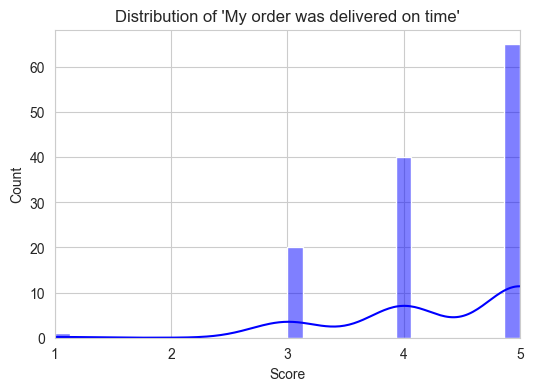

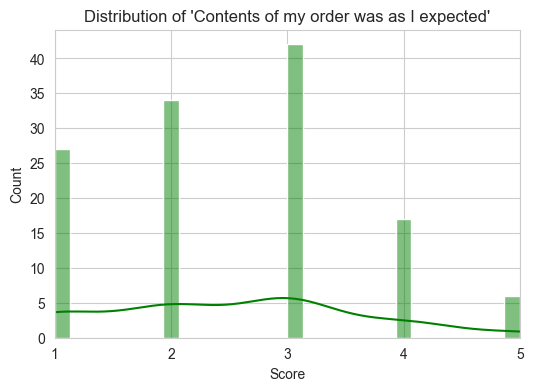

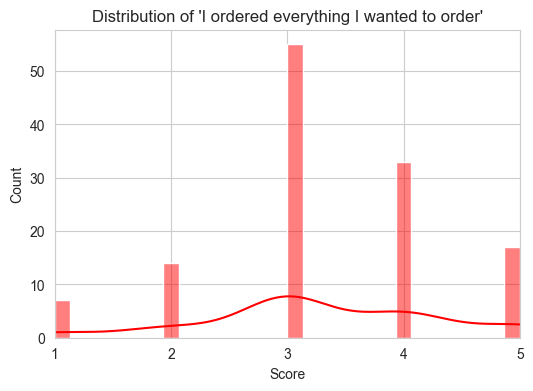

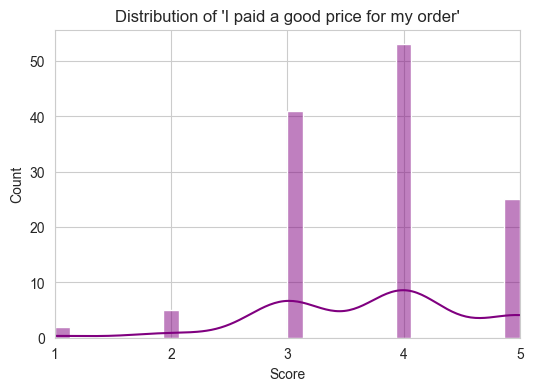

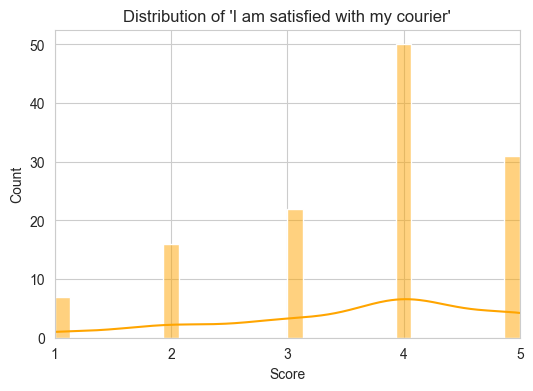

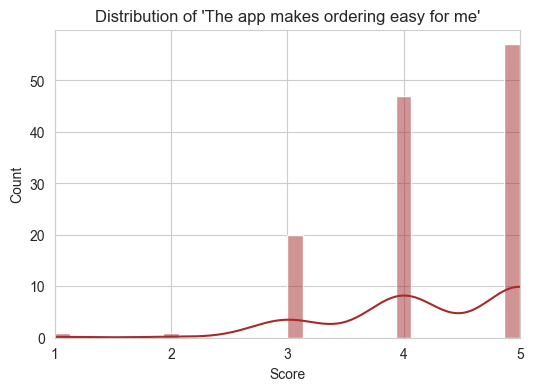

In [120]:
# Distributions for all features
features = ['delivery_timeliness', 'order_accuracy', 'product_availability', 'price_value_perception', 'courier_service_rating', 'app_usability']
titles = [
    "Distribution of 'My order was delivered on time'",
    "Distribution of 'Contents of my order was as I expected'",
    "Distribution of 'I ordered everything I wanted to order'",
    "Distribution of 'I paid a good price for my order'",
    "Distribution of 'I am satisfied with my courier'",
    "Distribution of 'The app makes ordering easy for me'"
]
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for feature, title, color in zip(features, titles, colors):
    plt.figure(figsize=(6, 4))
    sns.histplot(data[feature].dropna(), kde=True, bins=30, color=color)
    plt.title(title)
    plt.xlabel("Score")
    plt.xticks([1, 2, 3, 4, 5])
    plt.xlim(1, 5)
    plt.show()

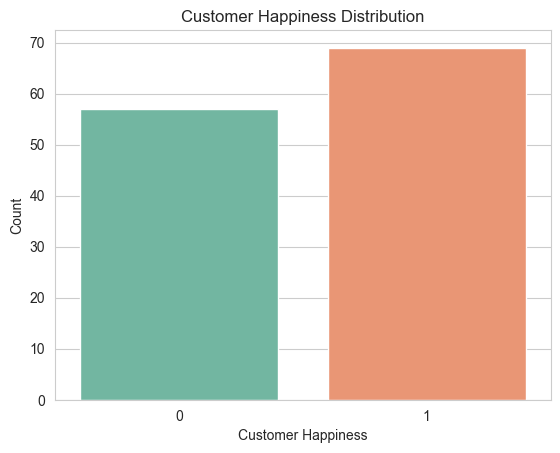

In [121]:
# Countplot for Categorical column
sns.countplot(x="customer_happiness", data=data, palette="Set2")
plt.title("Customer Happiness Distribution")
plt.xlabel("Customer Happiness")
plt.ylabel("Count")
plt.show()

# 4. Bivariate analysis.

## 4.1. Relationship each curtomer happiness and each feature.

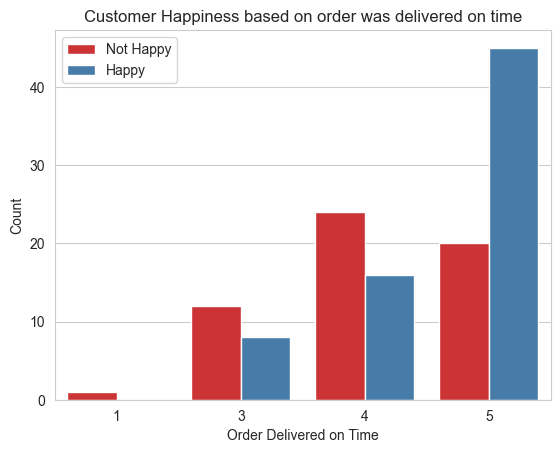

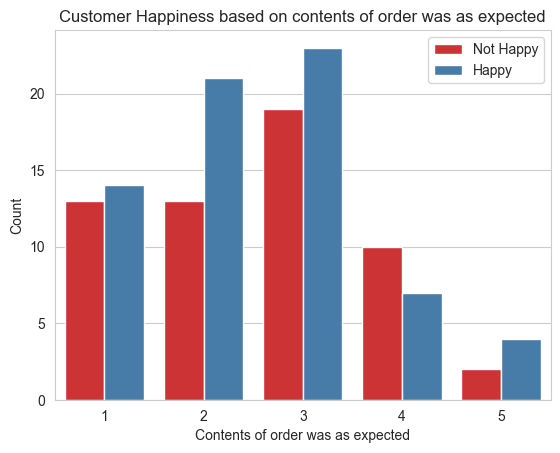

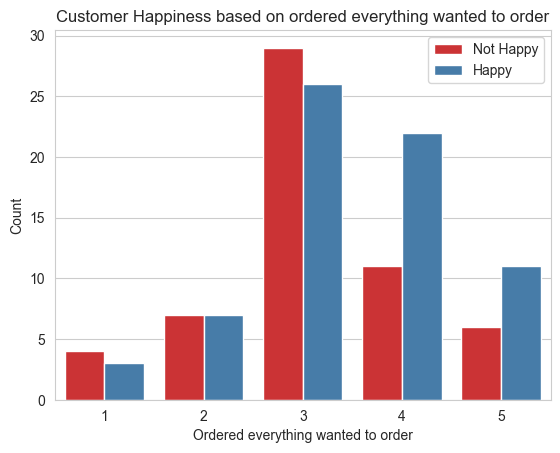

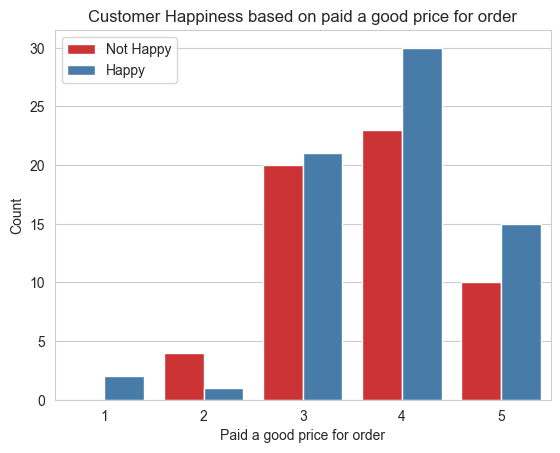

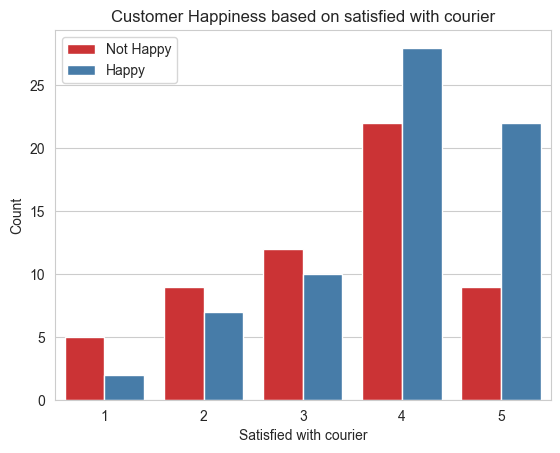

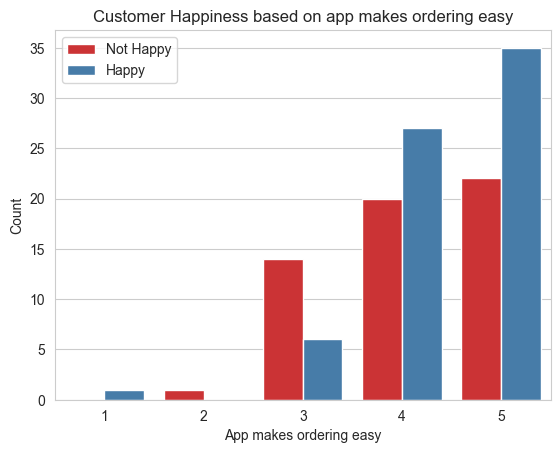

In [122]:
# Bivariate analysis: Relationship between each feature and customer_happiness
features = ['delivery_timeliness', 'order_accuracy', 'product_availability', 'price_value_perception', 'courier_service_rating', 'app_usability']
titles = [
    "Customer Happiness based on order was delivered on time",
    "Customer Happiness based on contents of order was as expected",
    "Customer Happiness based on ordered everything wanted to order",
    "Customer Happiness based on paid a good price for order",
    "Customer Happiness based on satisfied with courier",
    "Customer Happiness based on app makes ordering easy"
]
xlabels = [
    "Order Delivered on Time",
    "Contents of order was as expected",
    "Ordered everything wanted to order",
    "Paid a good price for order",
    "Satisfied with courier",
    "App makes ordering easy"
]

for feature, title, xlabel in zip(features, titles, xlabels):
    sns.countplot(x=feature, hue="customer_happiness", data=data, palette="Set1")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend(labels=['Not Happy', 'Happy'])
    plt.show()

# 5. Multivariate analysis.

## 5.1. All pairwise correlation.

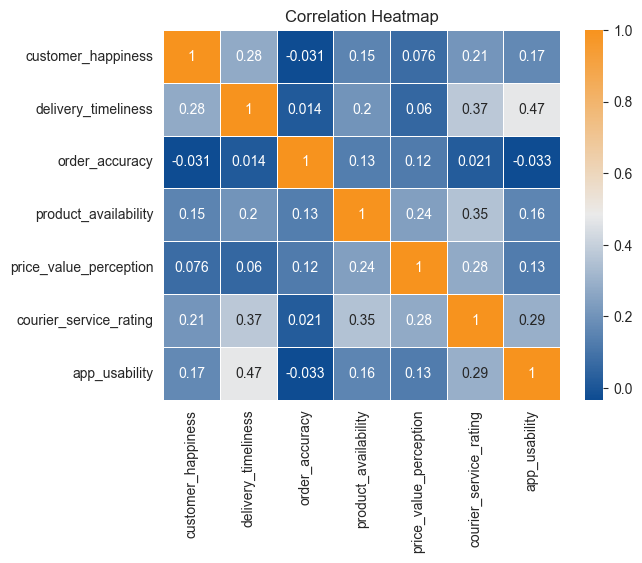

<Figure size 1600x1000 with 0 Axes>

In [123]:
colors_sentiment = ["#0E4C92", "#EAEAEA", "#F7931E"]
cmap_sentiment = LinearSegmentedColormap.from_list("sentiment", colors_sentiment)
ax = sns.heatmap(data.corr(method='kendall'), annot=True, cmap=cmap_sentiment, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.figure(figsize=(16, 10))
plt.show()

# 6. Split Training and Testing Data.

In [124]:
# Extract features and target variable
X = data.drop(columns=['customer_happiness'])
y = data['customer_happiness']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4, stratify=y)

In [125]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((100, 6), (100,), (26, 6), (26,))

# 7. Model building.

## 7.1. Logistic Regression.

In [126]:
# Train a linear regression model

# Create the Pipeline object
lr_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(random_state=4, max_iter=1000))
])

# Fit the Pipeline object to the training data
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work w

In [127]:
# Predictions
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

In [128]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.6153846153846154
ROC-AUC: 0.6547619047619048

Confusion Matrix
[[ 6  6]
 [ 4 10]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.60      0.50      0.55        12
       Happy       0.62      0.71      0.67        14

    accuracy                           0.62        26
   macro avg       0.61      0.61      0.61        26
weighted avg       0.61      0.62      0.61        26



In [129]:
# Access the model fitted within the pipeline
lr_model = lr_pipeline.named_steps['lr']

In [130]:
# Finding the most influential features
# Positive coefficient → increases probability of class 1.
# Negative coefficient → decreases probability of class 1.
# Larger magnitude → stronger influence.

lr_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient_LR": lr_model.coef_[0]
})

lr_coef_df["AbsCoefficient_LR"] = (
    lr_coef_df["Coefficient_LR"].abs()
)

lr_coef_df = lr_coef_df.sort_values(
    "AbsCoefficient_LR",
    ascending=False
)

print(lr_coef_df)

                  Feature  Coefficient_LR  AbsCoefficient_LR
5           app_usability        0.277943           0.277943
1          order_accuracy       -0.210906           0.210906
3  price_value_perception        0.182774           0.182774
0     delivery_timeliness        0.171600           0.171600
2    product_availability        0.106866           0.106866
4  courier_service_rating        0.101088           0.101088


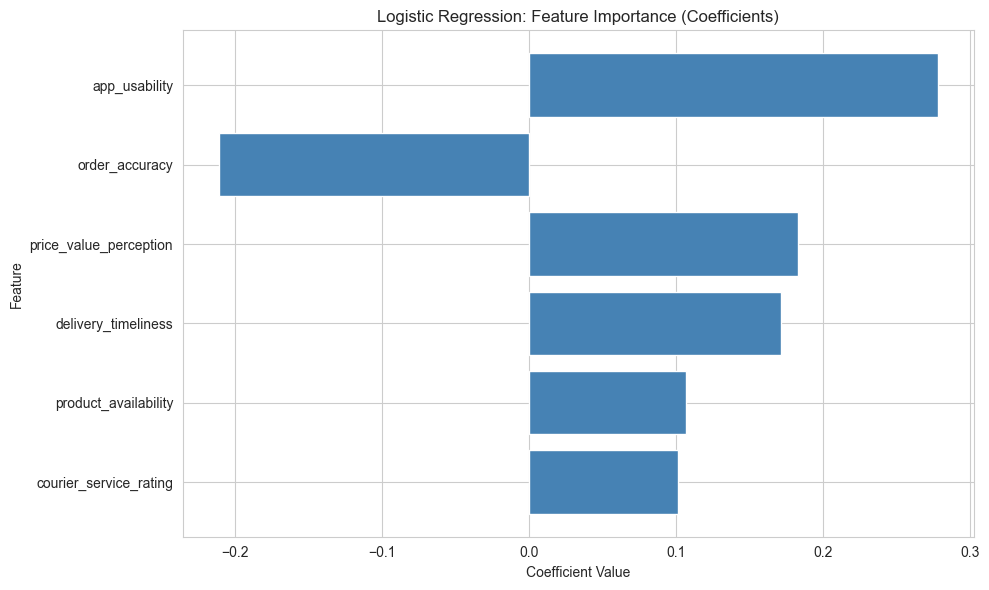

In [131]:

# Plotting feature importance (coefficients)
plt.figure(figsize=(10, 6))

plt.barh(
    lr_coef_df["Feature"],
    lr_coef_df["Coefficient_LR"],
    color='steelblue'
)

plt.gca().invert_yaxis()

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Logistic Regression: Feature Importance (Coefficients)")

plt.tight_layout()
plt.show()


In [132]:
# Odds ratios
# Odds Ratio > 1 → increases odds of class 1.
# Odds Ratio < 1 → decreases odds of class 1.
# Odds Ratio = 1.5 → 50% increase in odds for a one-unit increase in the feature.
# Odds Ratio = 0.5 → 50% decrease in odds.

odds_ratios = pd.DataFrame({
    "Feature": X.columns,
    "OddsRatio": np.exp(lr_model.coef_[0])
})

print(odds_ratios.sort_values("OddsRatio", ascending=False))

                  Feature  OddsRatio
5           app_usability   1.320410
3  price_value_perception   1.200543
0     delivery_timeliness   1.187203
2    product_availability   1.112786
4  courier_service_rating   1.106374
1          order_accuracy   0.809850


## 7.2. Random Forest.

In [133]:
# Train Random Forest

# Create the Pipeline object
rf_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=200, 
                                  max_depth=10, 
                                  min_samples_split=5, 
                                  min_samples_leaf=2, 
                                  random_state=4))
])

# Fit the Pipeline object to the training data
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


In [134]:
# Predictions
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [135]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.5769230769230769
ROC-AUC: 0.6785714285714286

Confusion Matrix
[[7 5]
 [6 8]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.54      0.58      0.56        12
       Happy       0.62      0.57      0.59        14

    accuracy                           0.58        26
   macro avg       0.58      0.58      0.58        26
weighted avg       0.58      0.58      0.58        26



In [136]:
# Access the model fitted within the pipeline
rf_model = rf_pipeline.named_steps['rf']

In [137]:
# Feature Importance
# Importance = 0.10 means shuffling that feature reduced ROC-AUC by about 0.10.
# Larger drops indicate more influential features.
result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=4,
    scoring="roc_auc"
)

rf_perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance_RF": result.importances_mean
})

perm_importance = rf_perm_importance.sort_values(
    "Importance_RF",
    ascending=False
)

print(perm_importance)

                  Feature  Importance_RF
0     delivery_timeliness       0.000000
3  price_value_perception       0.000000
5           app_usability       0.000000
4  courier_service_rating       0.000000
2    product_availability      -0.043155
1          order_accuracy      -0.058631


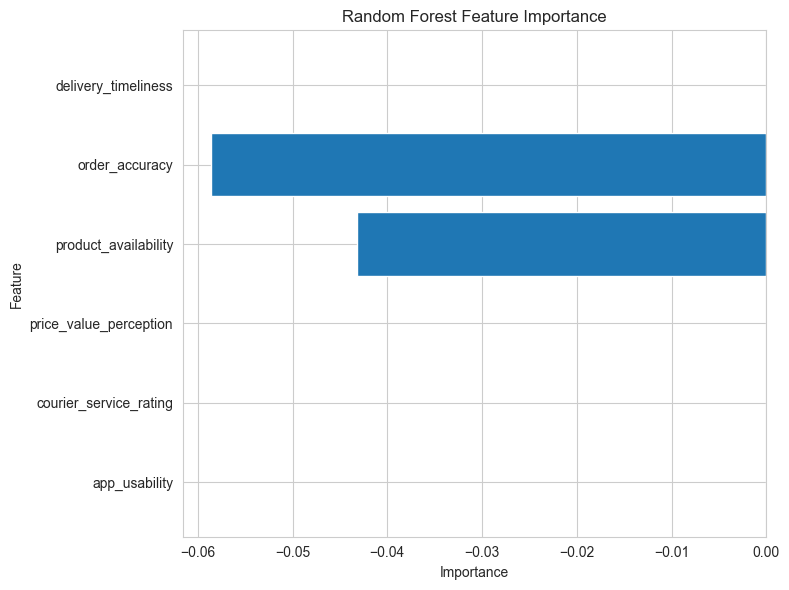

In [138]:
# Plotting feature importance
top_features = rf_perm_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance_RF"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

## 7.3. XGBoost (Gradient Boosting).

In [139]:
# Build xgb_model

# Create the Pipeline object
xgb_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("xgb", XGBClassifier(n_estimators=300, 
                          learning_rate=0.05, 
                          max_depth=4, 
                          subsample=0.8, 
                          colsample_bytree=0.8, 
                          random_state=4, eval_metric="logloss"))
])

# Fit the Pipeline object to the training data
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [140]:
# Predict
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [141]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.5769230769230769
ROC AUC: 0.6428571428571429

Confusion Matrix
[[8 4]
 [7 7]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.53      0.67      0.59        12
       Happy       0.64      0.50      0.56        14

    accuracy                           0.58        26
   macro avg       0.58      0.58      0.58        26
weighted avg       0.59      0.58      0.58        26



In [142]:
# Access the model fitted within the pipeline
xgb_model = xgb_pipeline.named_steps['xgb']

In [143]:
# Feature importance
xgb_importances_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance_XGB": xgb_model.feature_importances_
})

xgb_importances_df = xgb_importances_df.sort_values(
    by="Importance_XGB",
    ascending=False
)

print(xgb_importances_df.head(20))

                  Feature  Importance_XGB
5           app_usability        0.191030
0     delivery_timeliness        0.190093
2    product_availability        0.161179
1          order_accuracy        0.154044
3  price_value_perception        0.151928
4  courier_service_rating        0.151726


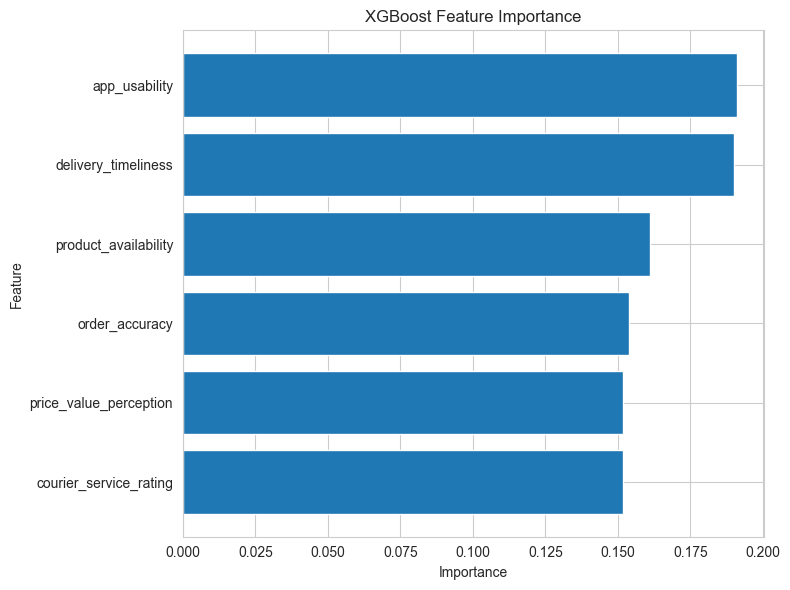

In [144]:
# Plotting feature importance
top_features = xgb_importances_df.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance_XGB"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

## 7.4. K-Nearest Neighbors (KNN) Classifier.

In [145]:
# Train KNN model

# Create the Pipeline object
knn_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# Fit the Pipeline object to the training data
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30


In [146]:
# Predict
knn_pred = knn_pipeline.predict(X_test)
knn_prob = knn_pipeline.predict_proba(X_test)[:, 1]

In [147]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("ROC-AUC:", roc_auc_score(y_test, knn_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.5
ROC-AUC: 0.5

Confusion Matrix
[[6 6]
 [7 7]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.46      0.50      0.48        12
       Happy       0.54      0.50      0.52        14

    accuracy                           0.50        26
   macro avg       0.50      0.50      0.50        26
weighted avg       0.50      0.50      0.50        26



In [148]:
# Access the model fitted within the pipeline
knn_model = knn_pipeline.named_steps['knn']

In [149]:
knn_perm_importance = permutation_importance(
    knn_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=4,
    scoring='roc_auc'
)

knn_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_KNN': knn_perm_importance.importances_mean
})

knn_importance_df = knn_importance_df.sort_values(
    by='Importance_KNN',
    ascending=False
)

print(knn_importance_df)

                  Feature  Importance_KNN
3  price_value_perception        0.016071
5           app_usability        0.000000
0     delivery_timeliness       -0.002083
2    product_availability       -0.020536
4  courier_service_rating       -0.037500
1          order_accuracy       -0.041667


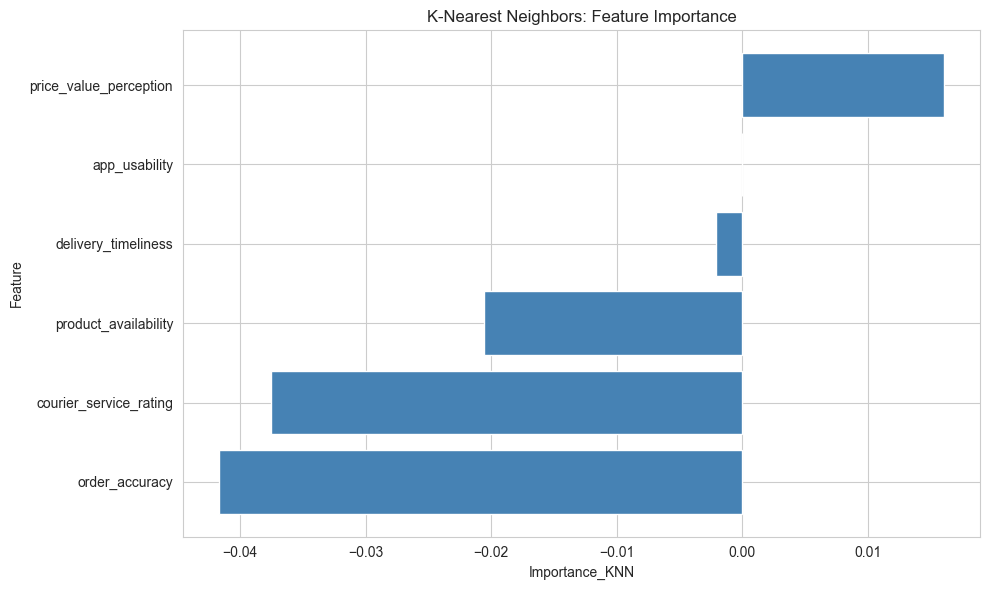

In [150]:
# Plotting feature importance (coefficients)
plt.figure(figsize=(10, 6))

plt.barh(
    knn_importance_df["Feature"],
    knn_importance_df["Importance_KNN"],
    color='steelblue'
)

plt.gca().invert_yaxis()

plt.xlabel("Importance_KNN")
plt.ylabel("Feature")
plt.title("K-Nearest Neighbors: Feature Importance")

plt.tight_layout()
plt.show()

## 7.5. Support Vector Machine (SVM).

In [151]:
# Train SVM model with RBF kernel

# Create the Pipeline object
svm_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("svm", SVC(kernel='rbf', 
                C=1.0, 
                gamma='scale', 
                probability=True, 
                random_state=4))
])

# Fit the Pipeline object to the training data
svm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [152]:
# Predict
svm_pred = svm_pipeline.predict(X_test)
svm_prob = svm_pipeline.predict_proba(X_test)[:, 1]

In [153]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("ROC-AUC:", roc_auc_score(y_test, svm_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, svm_pred))

print("\nClassification Report")
print(classification_report(y_test, svm_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.5769230769230769
ROC-AUC: 0.5892857142857142

Confusion Matrix
[[ 4  8]
 [ 3 11]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.57      0.33      0.42        12
       Happy       0.58      0.79      0.67        14

    accuracy                           0.58        26
   macro avg       0.58      0.56      0.54        26
weighted avg       0.58      0.58      0.55        26



In [154]:
# Access the model fitted within the pipeline
svm_model = svm_pipeline.named_steps['svm']

In [155]:
# Feature Importance using permutation importance
svm_perm_importance = permutation_importance(
    svm_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=4,
    scoring='roc_auc'
)

svm_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance_SVM": svm_perm_importance.importances_mean
})

svm_importance_df = svm_importance_df.sort_values(
    "Importance_SVM",
    ascending=False
)

print(svm_importance_df)

                  Feature  Importance_SVM
3  price_value_perception        0.083333
5           app_usability        0.082143
2    product_availability        0.065476
4  courier_service_rating        0.033929
1          order_accuracy        0.010119
0     delivery_timeliness       -0.020833


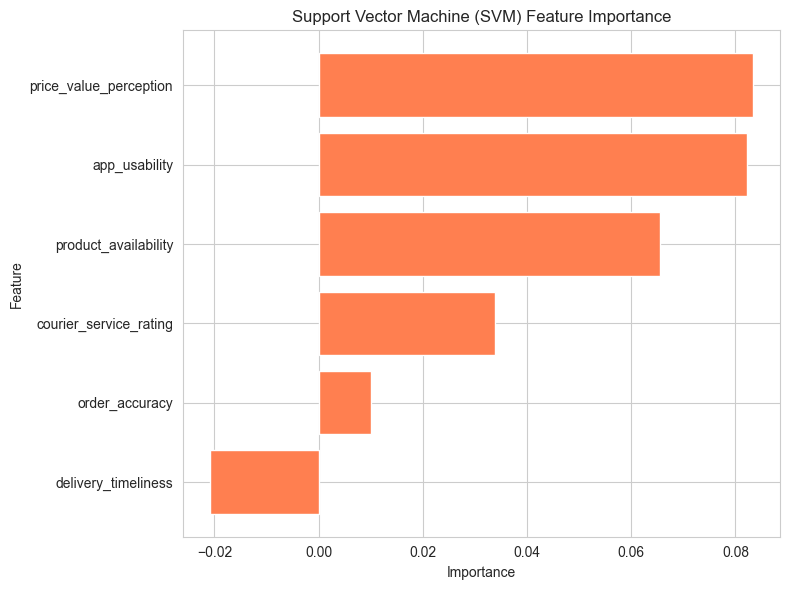

In [156]:
# Plotting feature importance for SVM
top_features = svm_importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance_SVM"],
    color='coral'
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Support Vector Machine (SVM) Feature Importance")

plt.tight_layout()
plt.show()

## 7.6. Naive Bayes.

In [157]:
# Train Naive Bayes model

# Create the Pipeline object
nb_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("nb", GaussianNB())
])

# Fit the Pipeline object to the training data
nb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('nb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [158]:
# Predict
nb_pred = nb_pipeline.predict(X_test)
nb_prob = nb_pipeline.predict_proba(X_test)[:, 1]

In [159]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("ROC-AUC:", roc_auc_score(y_test, nb_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, nb_pred))

print("\nClassification Report")
print(classification_report(y_test, nb_pred, target_names=['Unhappy', 'Happy']))

Accuracy: 0.6153846153846154
ROC-AUC: 0.6964285714285714

Confusion Matrix
[[ 6  6]
 [ 4 10]]

Classification Report
              precision    recall  f1-score   support

     Unhappy       0.60      0.50      0.55        12
       Happy       0.62      0.71      0.67        14

    accuracy                           0.62        26
   macro avg       0.61      0.61      0.61        26
weighted avg       0.61      0.62      0.61        26



In [160]:
# Access the model fitted within the pipeline
nb_model = nb_pipeline.named_steps['nb']

In [161]:
# Feature Importance using permutation importance
nb_perm_importance = permutation_importance(
    nb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=4,
    scoring='roc_auc'
)

nb_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance_NB": nb_perm_importance.importances_mean
})

nb_importance_df = nb_importance_df.sort_values(
    "Importance_NB",
    ascending=False
)

print(nb_importance_df)

                  Feature  Importance_NB
0     delivery_timeliness       0.042857
2    product_availability       0.038095
4  courier_service_rating       0.008333
5           app_usability       0.008333
3  price_value_perception       0.001786
1          order_accuracy      -0.039881


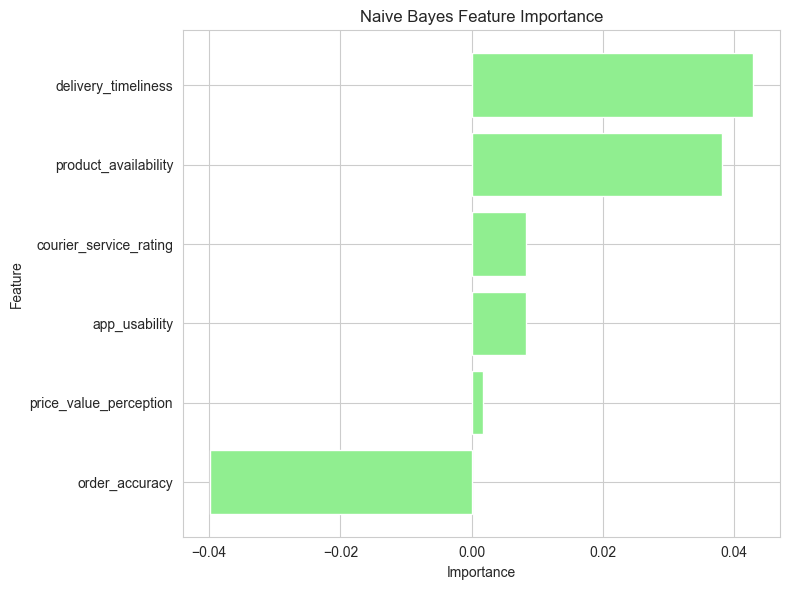

In [162]:
# Plotting feature importance for Naive Bayes
top_features = nb_importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance_NB"],
    color='lightgreen'
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Naive Bayes Feature Importance")

plt.tight_layout()
plt.show()

# 8. Model comparison.

## 8.1. Rank each feature based on importance.

In [163]:
# Convert importance values to ranks

lr_coef_df['Rank_LR'] = lr_coef_df["AbsCoefficient_LR"].rank(ascending=False, method='dense').astype(int)

rf_perm_importance['Rank_RF'] = rf_perm_importance["Importance_RF"].rank(ascending=False, method='dense').astype(int)

xgb_importances_df['Rank_XGB'] = xgb_importances_df["Importance_XGB"].rank(ascending=False, method='dense').astype(int)

knn_importance_df['Rank_KNN'] = knn_importance_df["Importance_KNN"].rank(ascending=False, method='dense').astype(int)

svm_importance_df['Rank_SVM'] = svm_importance_df["Importance_SVM"].rank(ascending=False, method='dense').astype(int)

nb_importance_df['Rank_NB'] = nb_importance_df["Importance_NB"].rank(ascending=False, method='dense').astype(int)

print(lr_coef_df.head(10))
print("\n", rf_perm_importance.head(10))
print("\n", xgb_importances_df.head(10))
print("\n", knn_importance_df.head(10))
print("\n", svm_importance_df.head(10))
print("\n", nb_importance_df.head(10))

print("All models ranked successfully")

                  Feature  Coefficient_LR  AbsCoefficient_LR  Rank_LR
5           app_usability        0.277943           0.277943        1
1          order_accuracy       -0.210906           0.210906        2
3  price_value_perception        0.182774           0.182774        3
0     delivery_timeliness        0.171600           0.171600        4
2    product_availability        0.106866           0.106866        5
4  courier_service_rating        0.101088           0.101088        6

                   Feature  Importance_RF  Rank_RF
0     delivery_timeliness       0.000000        1
1          order_accuracy      -0.058631        3
2    product_availability      -0.043155        2
3  price_value_perception       0.000000        1
4  courier_service_rating       0.000000        1
5           app_usability       0.000000        1

                   Feature  Importance_XGB  Rank_XGB
5           app_usability        0.191030         1
0     delivery_timeliness        0.190093         2


## 8.2. Calculate the average importance rank.

In [164]:
importance_compare = (
    lr_coef_df[['Feature','Rank_LR']]
    .merge(
        rf_perm_importance[['Feature','Rank_RF']],
        on='Feature'
    )
    .merge(
        xgb_importances_df[['Feature','Rank_XGB']],
        on='Feature'
    )
    .merge(
        knn_importance_df[['Feature','Rank_KNN']],
        on='Feature'
    )
    .merge(
        svm_importance_df[['Feature','Rank_SVM']],
        on='Feature'
    )
    .merge(
        nb_importance_df[['Feature','Rank_NB']],
        on='Feature'
    )
)

importance_compare['Average_Rank'] = (
    importance_compare[
        ['Rank_LR','Rank_RF','Rank_XGB','Rank_KNN','Rank_SVM','Rank_NB']
    ].mean(axis=1)
)

importance_compare.sort_values('Average_Rank')

,Feature,Rank_LR,Rank_RF,Rank_XGB,Rank_KNN,Rank_SVM,Rank_NB,Average_Rank
0,app_usability,1,1,1,2,2,4,1.833333
2,price_value_perception,3,1,5,1,1,5,2.666667
3,delivery_timeliness,4,1,2,3,6,1,2.833333
4,product_availability,5,2,3,4,3,2,3.166667
5,courier_service_rating,6,1,6,5,4,3,4.166667
1,order_accuracy,2,3,4,6,5,6,4.333333


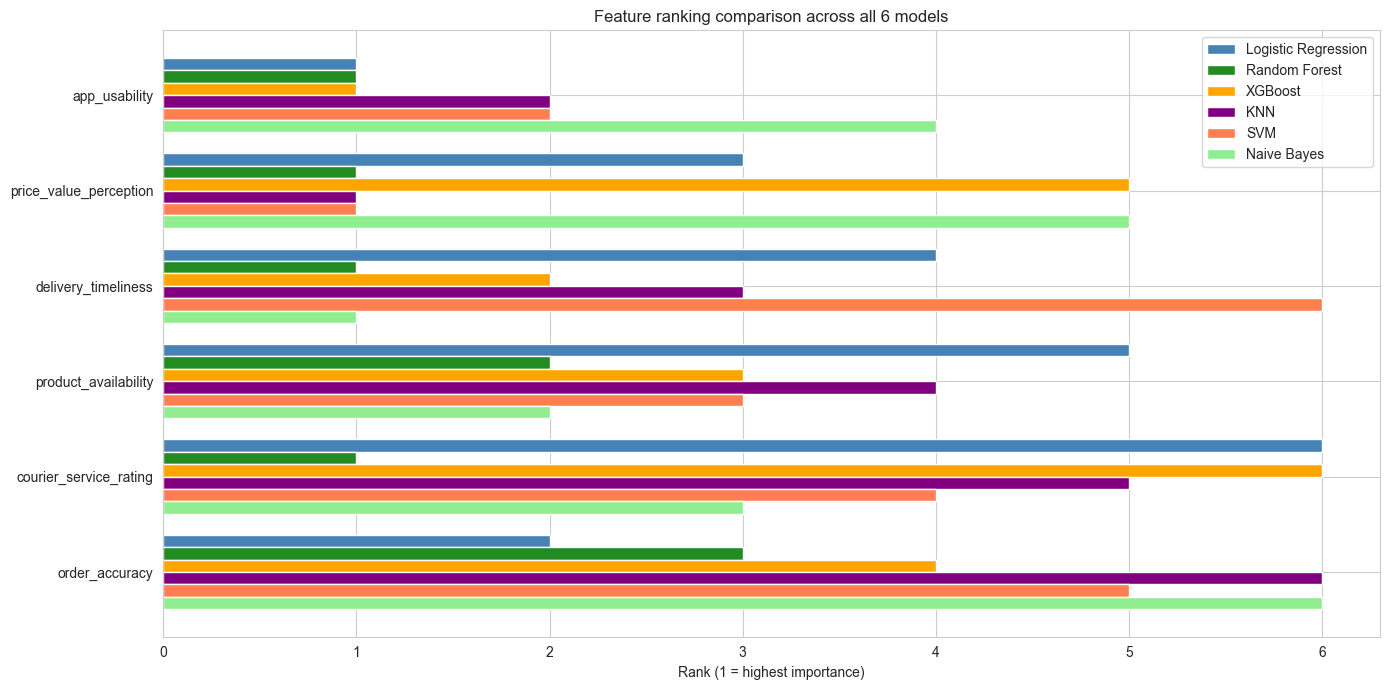

In [165]:
# Plot the feature ranking across all models
rank_plot = importance_compare.sort_values('Average_Rank')
rank_plot['Feature'] = pd.Categorical(
    rank_plot['Feature'],
    categories=rank_plot['Feature'],
    ordered=True
)

plt.figure(figsize=(14, 7))
indices  = np.arange(len(rank_plot))
height = 0.13

plt.barh(indices - 2.5*height, rank_plot['Rank_LR'], height, label='Logistic Regression', color='steelblue')
plt.barh(indices - 1.5*height, rank_plot['Rank_RF'], height, label='Random Forest', color='forestgreen')
plt.barh(indices - 0.5*height, rank_plot['Rank_XGB'], height, label='XGBoost', color='orange')
plt.barh(indices + 0.5*height, rank_plot['Rank_KNN'], height, label='KNN', color='purple')
plt.barh(indices + 1.5*height, rank_plot['Rank_SVM'], height, label='SVM', color='coral')
plt.barh(indices + 2.5*height, rank_plot['Rank_NB'], height, label='Naive Bayes', color='lightgreen')

plt.yticks(indices, rank_plot['Feature'])
plt.gca().invert_yaxis()
plt.xlabel('Rank (1 = highest importance)')
plt.title('Feature ranking comparison across all 6 models')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

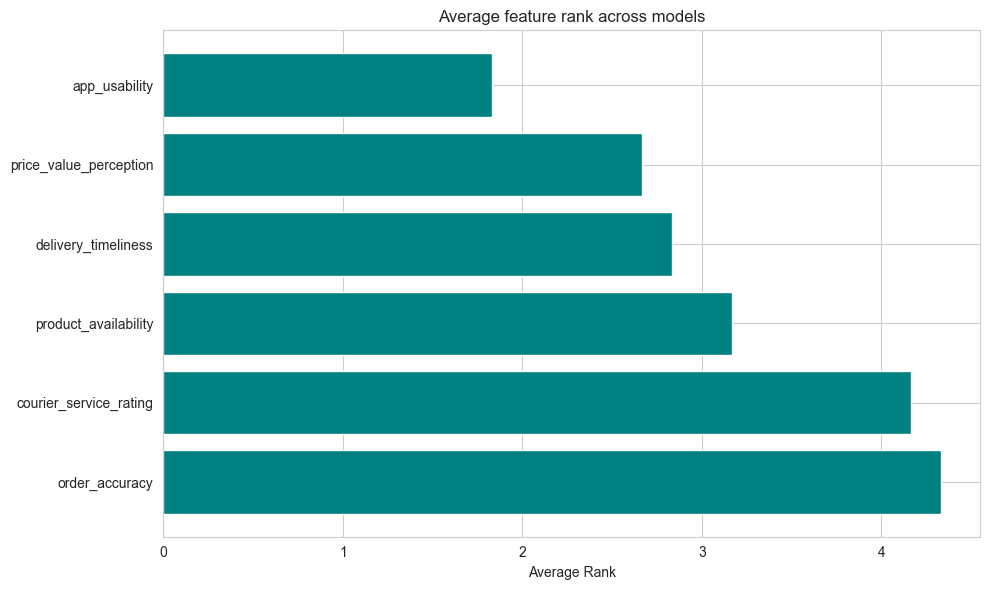

In [166]:

# Plot average rank separately
plt.figure(figsize=(10, 6))
plt.barh(rank_plot['Feature'], rank_plot['Average_Rank'], color='teal')
plt.gca().invert_yaxis()
plt.xlabel('Average Rank')
plt.title('Average feature rank across models')
plt.tight_layout()
plt.show()

## 8.3. Compare Accuracy, ROC AUC, confusion matrix for all models.

In [167]:
# Model comparison: accuracy, ROC AUC, confusion matrix, and classification report
comparison_results = []
for model_name, pred, prob in [
    ("Logistic Regression", lr_pred, lr_prob),
    ("Random Forest", rf_pred, rf_prob),
    ("XGBoost", xgb_pred, xgb_prob),
    ("KNN", knn_pred, knn_prob),
    ("SVM", svm_pred, svm_prob),
    ("Naive Bayes", nb_pred, nb_prob)
]:
    comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "Confusion_Matrix": confusion_matrix(y_test, pred),
        "Classification_Report": classification_report(
            y_test,
            pred,
            target_names=["Unhappy", "Happy"]
        )
    })

comparison_df = pd.DataFrame(comparison_results).set_index("Model")

print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(comparison_df[["Accuracy", "ROC_AUC"]])

for result in comparison_results:
    print(f"\n{'=' * 60}")
    print(f"{result['Model'].upper()}")
    print(f"{'=' * 60}")
    print("Confusion Matrix:")
    print(result["Confusion_Matrix"])
    print("\nClassification Report:")
    print(result["Classification_Report"])

MODEL COMPARISON SUMMARY
                     Accuracy   ROC_AUC
Model                                  
Logistic Regression  0.615385  0.654762
Random Forest        0.576923  0.678571
XGBoost              0.576923  0.642857
KNN                  0.500000  0.500000
SVM                  0.576923  0.589286
Naive Bayes          0.615385  0.696429

LOGISTIC REGRESSION
Confusion Matrix:
[[ 6  6]
 [ 4 10]]

Classification Report:
              precision    recall  f1-score   support

     Unhappy       0.60      0.50      0.55        12
       Happy       0.62      0.71      0.67        14

    accuracy                           0.62        26
   macro avg       0.61      0.61      0.61        26
weighted avg       0.61      0.62      0.61        26


RANDOM FOREST
Confusion Matrix:
[[7 5]
 [6 8]]

Classification Report:
              precision    recall  f1-score   support

     Unhappy       0.54      0.58      0.56        12
       Happy       0.62      0.57      0.59        14

    accura

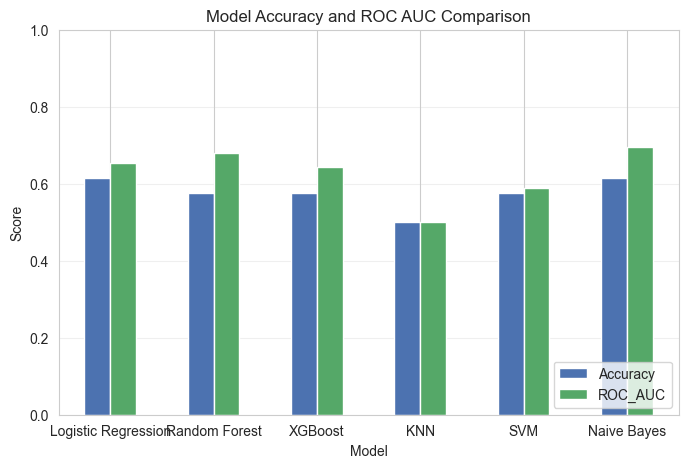

In [168]:
metric_df = comparison_df[["Accuracy", "ROC_AUC"]].copy()
metric_df.plot(
kind="bar",
figsize=(8, 5),
rot=0,
color=["#4C72B0", "#55A868"]
)
plt.title("Model Accuracy and ROC AUC Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 9. SHAP to find feature importance.

## 9.1. SHAP on Logistic Regression.

### 9.1.1. Find feature importance.

In [169]:
# Create a SHAP explainer for the logistic regression model
explainer = shap.LinearExplainer(lr_model, X)
lr_shap_values = explainer.shap_values(X)

Background dataset has 126 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=126 when initializing the masker.


In [170]:
print(lr_shap_values.shape)
# Print the first 5 SHAP values for the logistic regression model
print(lr_shap_values[:5])

(126, 6)
[[-0.22822827 -0.08858051 -0.03740322  0.05117673 -0.16477364 -0.05836794]
 [-0.22822827  0.12232547 -0.03740322  0.23395077  0.03740261 -0.33631051]
 [ 0.11497213 -0.08858051 -0.03740322 -0.13159731 -0.06368552  0.21957463]
 [ 0.11497213 -0.29948648 -0.03740322 -0.13159731 -0.06368552  0.21957463]
 [ 0.11497213 -0.29948648 -0.03740322 -0.13159731 -0.06368552  0.21957463]]


In [171]:
# Use SHAP values for the positive class (happy customers)
# Calculate  mean SHAP and mean absolute SHAP per feature
lr_mean_shap = np.abs(lr_shap_values).mean(axis=0)  # shape: (6,)
lr_mean_direction = lr_shap_values.mean(axis=0)

lr_shap_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'LR_Mean_SHAP_Importance': lr_mean_shap,
    'LR_Mean_SHAP_Direction': lr_mean_direction
}).sort_values('LR_Mean_SHAP_Importance', ascending=False)

print(lr_shap_importance_df)

lr_most_important_feature = lr_shap_importance_df.iloc[0]
lr_least_important_feature = lr_shap_importance_df.iloc[-1]

print("\nMost important feature:")
print(lr_most_important_feature['Feature'])
print("Importance:", lr_most_important_feature['LR_Mean_SHAP_Importance'])

print("\nLeast important feature:")
print(lr_least_important_feature['Feature'])
print("Importance:", lr_least_important_feature['LR_Mean_SHAP_Importance'])

                  Feature  LR_Mean_SHAP_Importance  LR_Mean_SHAP_Direction
1          order_accuracy                 0.198653                0.010177
5           app_usability                 0.186442                0.012221
3  price_value_perception                 0.131133                0.004758
0     delivery_timeliness                 0.118050                0.000572
4  courier_service_rating                 0.095729                0.002102
2    product_availability                 0.088292               -0.004326

Most important feature:
order_accuracy
Importance: 0.19865334169281296

Least important feature:
product_availability
Importance: 0.08829195232757779


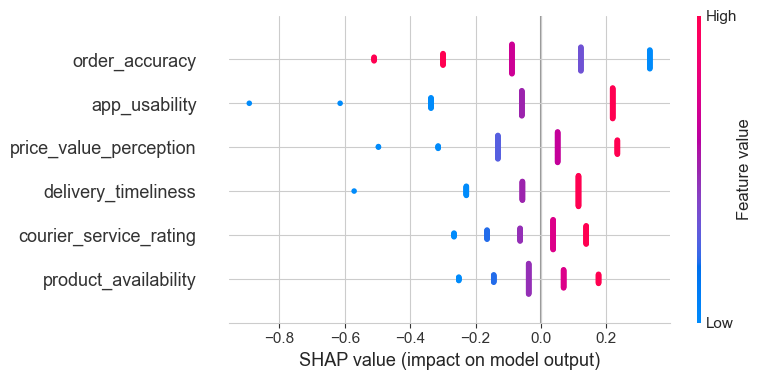

In [172]:
# Standard shap plot
shap.summary_plot(
    lr_shap_values,
    X
)

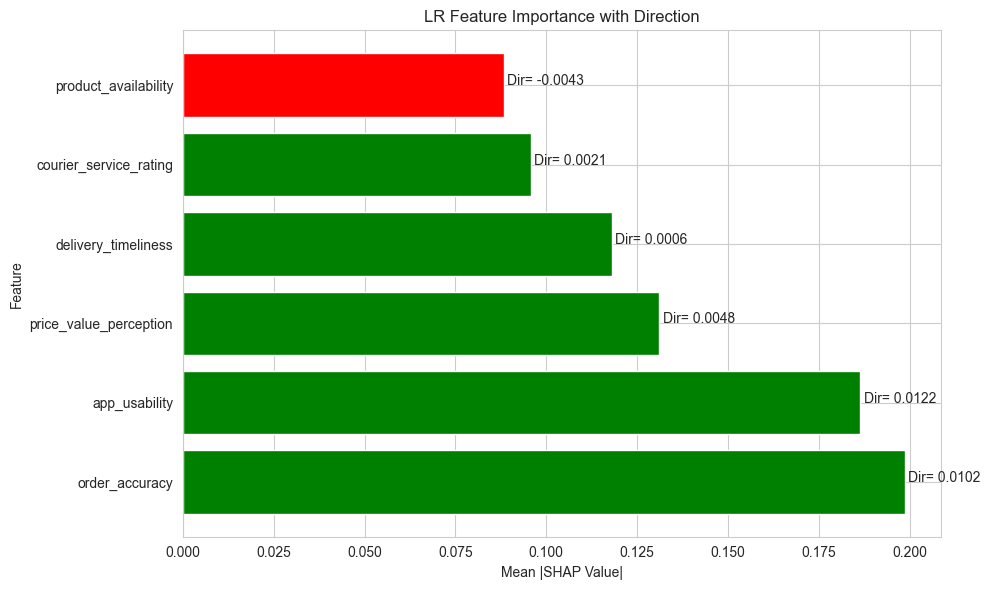

In [173]:
# Plot Mean Absolute SHAP importance per feature
# Create color based on direction
colors = [
    'green' if d > 0 else 'red'
    for d in lr_shap_importance_df['LR_Mean_SHAP_Direction']
]

plt.figure(figsize=(10,6))

plt.barh(
    lr_shap_importance_df['Feature'],
    lr_shap_importance_df['LR_Mean_SHAP_Importance'],
    color=colors
)

plt.title('LR Feature Importance with Direction')
plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')

for i, row in enumerate(lr_shap_importance_df.itertuples()):
    plt.text(
        row.LR_Mean_SHAP_Importance + 0.001,
        i,
        f"Dir= {row.LR_Mean_SHAP_Direction:.4f}"
    )

plt.tight_layout()
plt.show()

## 9.2. SHAP on Random Forest.

### 9.2.1. Find feature importance.

In [174]:
# Create a SHAP explainer for the random forest model
explainer = shap.TreeExplainer(rf_model)
rf_shap_values = explainer.shap_values(X)

In [175]:
print(rf_shap_values.shape)
# Print the first 5 SHAP values for the random forest model
print(rf_shap_values[:5])

(126, 6, 2)
[[[-0.0714611   0.0714611 ]
  [ 0.06285157 -0.06285157]
  [ 0.01195357 -0.01195357]
  [-0.0462543   0.0462543 ]
  [-0.05338023  0.05338023]
  [-0.01507195  0.01507195]]

 [[-0.0714611   0.0714611 ]
  [ 0.06285157 -0.06285157]
  [ 0.01195357 -0.01195357]
  [-0.0462543   0.0462543 ]
  [-0.05338023  0.05338023]
  [-0.01507195  0.01507195]]

 [[-0.0714611   0.0714611 ]
  [ 0.06285157 -0.06285157]
  [ 0.01195357 -0.01195357]
  [-0.0462543   0.0462543 ]
  [-0.05338023  0.05338023]
  [-0.01507195  0.01507195]]

 [[-0.0714611   0.0714611 ]
  [ 0.06285157 -0.06285157]
  [ 0.01195357 -0.01195357]
  [-0.0462543   0.0462543 ]
  [-0.05338023  0.05338023]
  [-0.01507195  0.01507195]]

 [[-0.0714611   0.0714611 ]
  [ 0.06285157 -0.06285157]
  [ 0.01195357 -0.01195357]
  [-0.0462543   0.0462543 ]
  [-0.05338023  0.05338023]
  [-0.01507195  0.01507195]]]


In [176]:
# Use SHAP values for the positive class (happy customers)
rf_shap_vals_happy_customers = rf_shap_values[:, :, 1]  # shape: (110, 6)

# Calculate  mean SHAP and mean absolute SHAP per feature
rf_mean_shap = np.abs(rf_shap_vals_happy_customers).mean(axis=0)  # shape: (6,)
rf_mean_direction = rf_shap_vals_happy_customers.mean(axis=0)

rf_shap_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'RF_Mean_SHAP_Importance': rf_mean_shap,
    'RF_Mean_SHAP_Direction': rf_mean_direction
}).sort_values('RF_Mean_SHAP_Importance', ascending=False)

print(rf_shap_importance_df)

rf_most_important_feature = rf_shap_importance_df.iloc[0]
rf_least_important_feature = rf_shap_importance_df.iloc[-1]

print("\nMost important feature:")
print(rf_most_important_feature['Feature'])
print("Importance:", rf_most_important_feature['RF_Mean_SHAP_Importance'])

print("\nLeast important feature:")
print(rf_least_important_feature['Feature'])
print("Importance:", rf_least_important_feature['RF_Mean_SHAP_Importance'])

                  Feature  RF_Mean_SHAP_Importance  RF_Mean_SHAP_Direction
0     delivery_timeliness                 0.071112                0.071112
1          order_accuracy                 0.066841               -0.066841
4  courier_service_rating                 0.052712                0.052712
3  price_value_perception                 0.044588                0.044588
5           app_usability                 0.014409                0.014409
2    product_availability                 0.013796               -0.009790

Most important feature:
delivery_timeliness
Importance: 0.07111206349247369

Least important feature:
product_availability
Importance: 0.013796070514647912


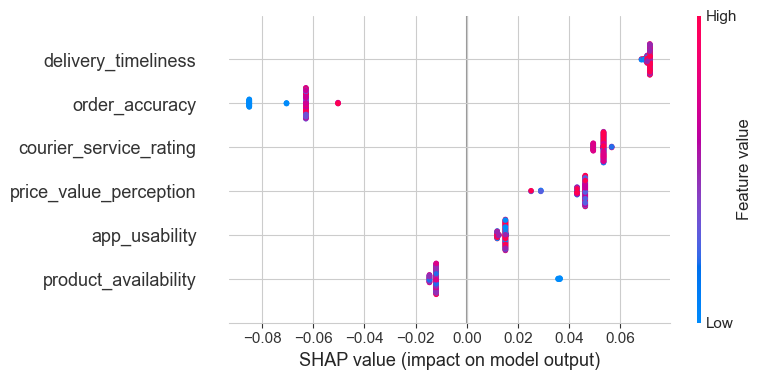

In [177]:
# Standard shap plot
shap.summary_plot(
    rf_shap_vals_happy_customers,
    X
)

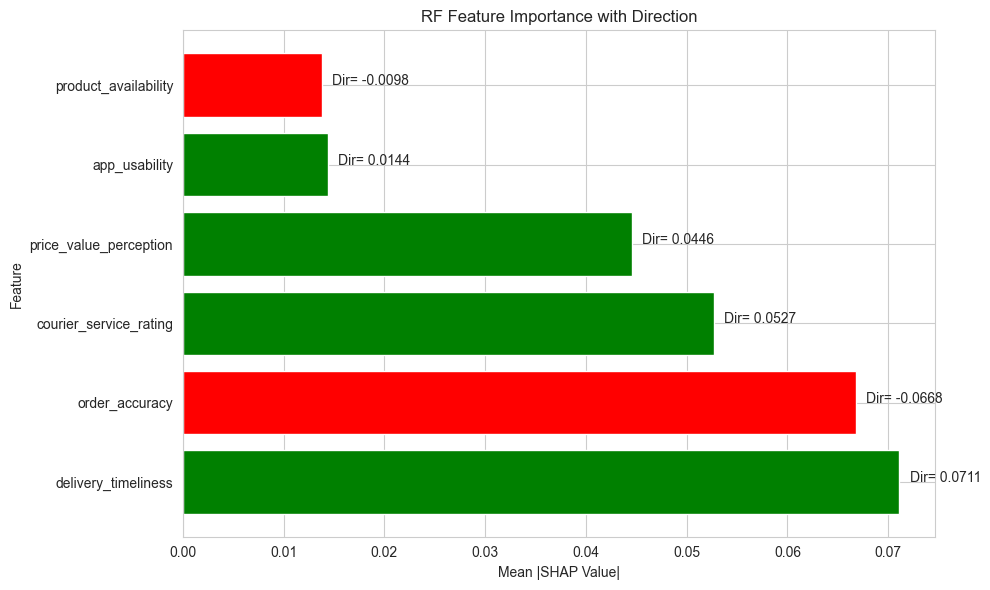

In [178]:
# Plot Mean Absolute SHAP importance per feature
# Create color based on direction
colors = [
    'green' if d > 0 else 'red'
    for d in rf_shap_importance_df['RF_Mean_SHAP_Direction']
]

plt.figure(figsize=(10,6))

plt.barh(
    rf_shap_importance_df['Feature'],
    rf_shap_importance_df['RF_Mean_SHAP_Importance'],
    color=colors
)

plt.title('RF Feature Importance with Direction')
plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')

for i, row in enumerate(rf_shap_importance_df.itertuples()):
    plt.text(
        row.RF_Mean_SHAP_Importance + 0.001,
        i,
        f"Dir= {row.RF_Mean_SHAP_Direction:.4f}"
    )

plt.tight_layout()
plt.show()

## 9.3. SHAP on KNN.

### 9.3.1. Find feature importance.

In [179]:
# Select a background sample (for efficiency)
background = shap.sample(X, 100, random_state=4)

# Create a KernelExplainer for KNN
explainer = shap.KernelExplainer(
    knn_model.predict_proba,
    background
)
knn_shap_values = explainer.shap_values(X)

  0%|          | 0/126 [00:00<?, ?it/s]

In [180]:
print(knn_shap_values.shape)
# Print the first 5 SHAP values for the KNN model
print(knn_shap_values[:5])

(126, 6, 2)
[[[ 6.66666667e-05 -6.66666667e-05]
  [ 5.92666667e-02 -5.92666667e-02]
  [ 1.80666667e-02 -1.80666667e-02]
  [ 1.17333333e-02 -1.17333333e-02]
  [ 5.49333333e-02 -5.49333333e-02]
  [-6.66666667e-05  6.66666667e-05]]

 [[ 1.00000000e-04 -1.00000000e-04]
  [-5.23000000e-02  5.23000000e-02]
  [ 3.03333333e-03 -3.03333333e-03]
  [-2.46333333e-02  2.46333333e-02]
  [ 1.78666667e-02 -1.78666667e-02]
  [-6.66666667e-05  6.66666667e-05]]

 [[ 0.00000000e+00  0.00000000e+00]
  [ 9.18333333e-02 -9.18333333e-02]
  [ 9.50000000e-03 -9.50000000e-03]
  [ 1.45000000e-02 -1.45000000e-02]
  [ 2.81666667e-02 -2.81666667e-02]
  [ 0.00000000e+00  0.00000000e+00]]

 [[ 0.00000000e+00  0.00000000e+00]
  [-3.16666667e-03  3.16666667e-03]
  [ 4.16666667e-03 -4.16666667e-03]
  [-5.65000000e-02  5.65000000e-02]
  [-5.00000000e-04  5.00000000e-04]
  [ 0.00000000e+00  0.00000000e+00]]

 [[ 0.00000000e+00  0.00000000e+00]
  [-3.16666667e-03  3.16666667e-03]
  [ 4.16666667e-03 -4.16666667e-03]
  [-5.65

In [181]:
# Use SHAP values for the positive class (happy customers)
knn_shap_vals_happy_customers = knn_shap_values[:, :, 1]  # shape: (110, 6)

# Calculate  mean SHAP and mean absolute SHAP per feature
knn_mean_shap = np.abs(knn_shap_vals_happy_customers).mean(axis=0)  # shape: (6,)
knn_mean_direction = knn_shap_vals_happy_customers.mean(axis=0)

knn_shap_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'KNN_Mean_SHAP_Importance': knn_mean_shap,
    'KNN_Mean_SHAP_Direction': knn_mean_direction
}).sort_values('KNN_Mean_SHAP_Importance', ascending=False)

print(knn_shap_importance_df)

knn_most_important_feature = knn_shap_importance_df.iloc[0]
knn_least_important_feature = knn_shap_importance_df.iloc[-1]

print("\nMost important feature:")
print(knn_most_important_feature['Feature'])
print("Importance:", knn_most_important_feature['KNN_Mean_SHAP_Importance'])

print("\nLeast important feature:")
print(knn_least_important_feature['Feature'])
print("Importance:", knn_least_important_feature['KNN_Mean_SHAP_Importance'])

                  Feature  KNN_Mean_SHAP_Importance  KNN_Mean_SHAP_Direction
1          order_accuracy                  0.057687                -0.005377
4  courier_service_rating                  0.028184                -0.005295
2    product_availability                  0.028096                -0.002897
3  price_value_perception                  0.015693                -0.000272
0     delivery_timeliness                  0.000067                -0.000002
5           app_usability                  0.000058                 0.000001

Most important feature:
order_accuracy
Importance: 0.057687037037037106

Least important feature:
app_usability
Importance: 5.7671957671949416e-05


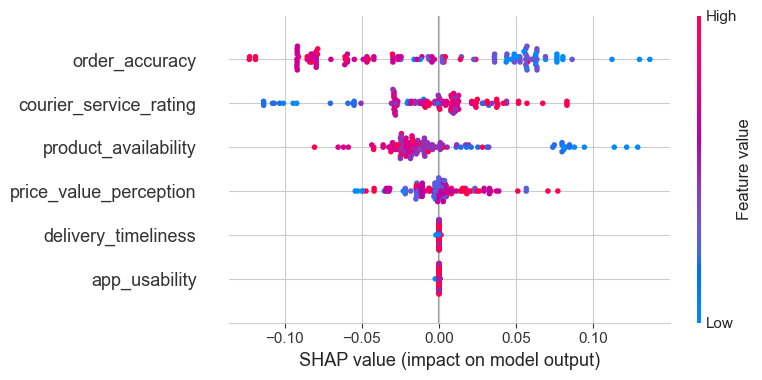

In [182]:
# Standard shap plot
shap.summary_plot(
    knn_shap_vals_happy_customers,
    X
)

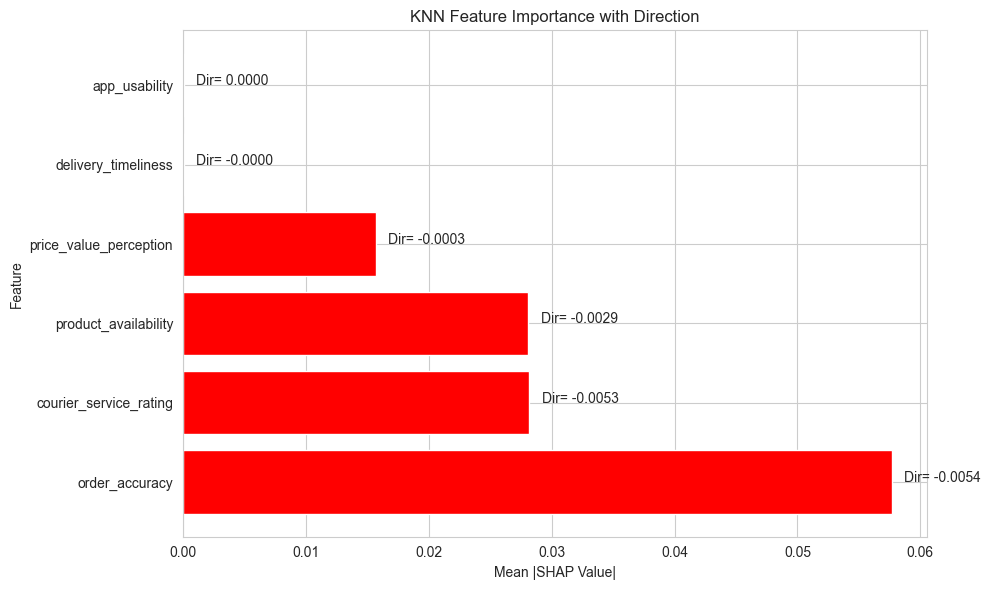

In [183]:
# Plot Mean Absolute SHAP importance per feature
# Create color based on direction
colors = [
    'green' if d > 0 else 'red'
    for d in knn_shap_importance_df['KNN_Mean_SHAP_Direction']
]

plt.figure(figsize=(10,6))

plt.barh(
    knn_shap_importance_df['Feature'],
    knn_shap_importance_df['KNN_Mean_SHAP_Importance'],
    color=colors
)

plt.title('KNN Feature Importance with Direction')
plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')

for i, row in enumerate(knn_shap_importance_df.itertuples()):
    plt.text(
        row.KNN_Mean_SHAP_Importance + 0.001,
        i,
        f"Dir= {row.KNN_Mean_SHAP_Direction:.4f}"
    )

plt.tight_layout()
plt.show()

## 9.4. SHAP on SVM

### 9.4.1. Find feature importance.

In [184]:
# Select a background sample
background = shap.sample(X, 100, random_state=4)

# Create the explainer
explainer = shap.KernelExplainer(
    svm_model.predict_proba,
    background
)

# Calculate SHAP values
svm_shap_values = explainer.shap_values(X)

  0%|          | 0/126 [00:00<?, ?it/s]

In [185]:
print(svm_shap_values.shape)
# Print the first 5 SHAP values for the SVM model
print(svm_shap_values[:5])

(126, 6, 2)
[[[-7.50598332e-04  7.50598332e-04]
  [-2.47874890e-05  2.47874890e-05]
  [-5.44804691e-05  5.44804691e-05]
  [ 4.27038929e-04 -4.27038929e-04]
  [-6.45550018e-04  6.45550018e-04]
  [ 1.18446499e-04 -1.18446499e-04]]

 [[-4.54683980e-04  4.54683980e-04]
  [-8.95764448e-05  8.95764448e-05]
  [ 0.00000000e+00  0.00000000e+00]
  [ 9.20624793e-04 -9.20624793e-04]
  [ 4.20180748e-04 -4.20180748e-04]
  [-4.94815246e-04  4.94815246e-04]]

 [[ 4.20941220e-04 -4.20941220e-04]
  [ 0.00000000e+00  0.00000000e+00]
  [ 1.80220588e-05 -1.80220588e-05]
  [-6.29764686e-05  6.29764686e-05]
  [ 8.38893528e-06 -8.38893528e-06]
  [ 4.10101274e-04 -4.10101274e-04]]

 [[ 3.71523817e-04 -3.71523817e-04]
  [ 1.07774968e-04 -1.07774968e-04]
  [ 2.02471577e-05 -2.02471577e-05]
  [-5.23657440e-05  5.23657440e-05]
  [ 1.24217636e-05 -1.24217636e-05]
  [ 3.60692991e-04 -3.60692991e-04]]

 [[ 3.71523817e-04 -3.71523817e-04]
  [ 1.07774968e-04 -1.07774968e-04]
  [ 2.02471577e-05 -2.02471577e-05]
  [-5.23

In [186]:
# Use SHAP values for the positive class (happy customers)
svm_shap_vals_happy_customers = svm_shap_values[:, :, 1]  # shape: (110, 6)

# Calculate  mean SHAP and mean absolute SHAP per feature
svm_mean_shap = np.abs(svm_shap_vals_happy_customers).mean(axis=0)  # shape: (6,)
svm_mean_direction = svm_shap_vals_happy_customers.mean(axis=0)

svm_shap_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'SVM_Mean_SHAP_Importance': svm_mean_shap,
    'SVM_Mean_SHAP_Direction': svm_mean_direction
}).sort_values('SVM_Mean_SHAP_Importance', ascending=False)

print(svm_shap_importance_df)

svm_most_important_feature = svm_shap_importance_df.iloc[0]
svm_least_important_feature = svm_shap_importance_df.iloc[-1]

print("\nMost important feature:")
print(svm_most_important_feature['Feature'])
print("Importance:", svm_most_important_feature['SVM_Mean_SHAP_Importance'])

print("\nLeast important feature:")
print(svm_least_important_feature['Feature'])
print("Importance:", svm_least_important_feature['SVM_Mean_SHAP_Importance'])

                  Feature  SVM_Mean_SHAP_Importance  SVM_Mean_SHAP_Direction
0     delivery_timeliness                  0.000421                 0.000008
4  courier_service_rating                  0.000369                 0.000029
5           app_usability                  0.000360                 0.000020
3  price_value_perception                  0.000275                -0.000004
2    product_availability                  0.000170                -0.000008
1          order_accuracy                  0.000073                 0.000001

Most important feature:
delivery_timeliness
Importance: 0.00042142800106314334

Least important feature:
order_accuracy
Importance: 7.260653087504037e-05


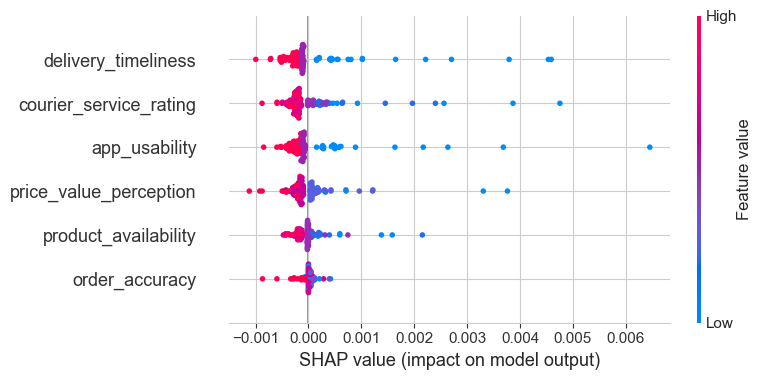

In [187]:
# Standard shap plot
shap.summary_plot(
    svm_shap_vals_happy_customers,
    X
)

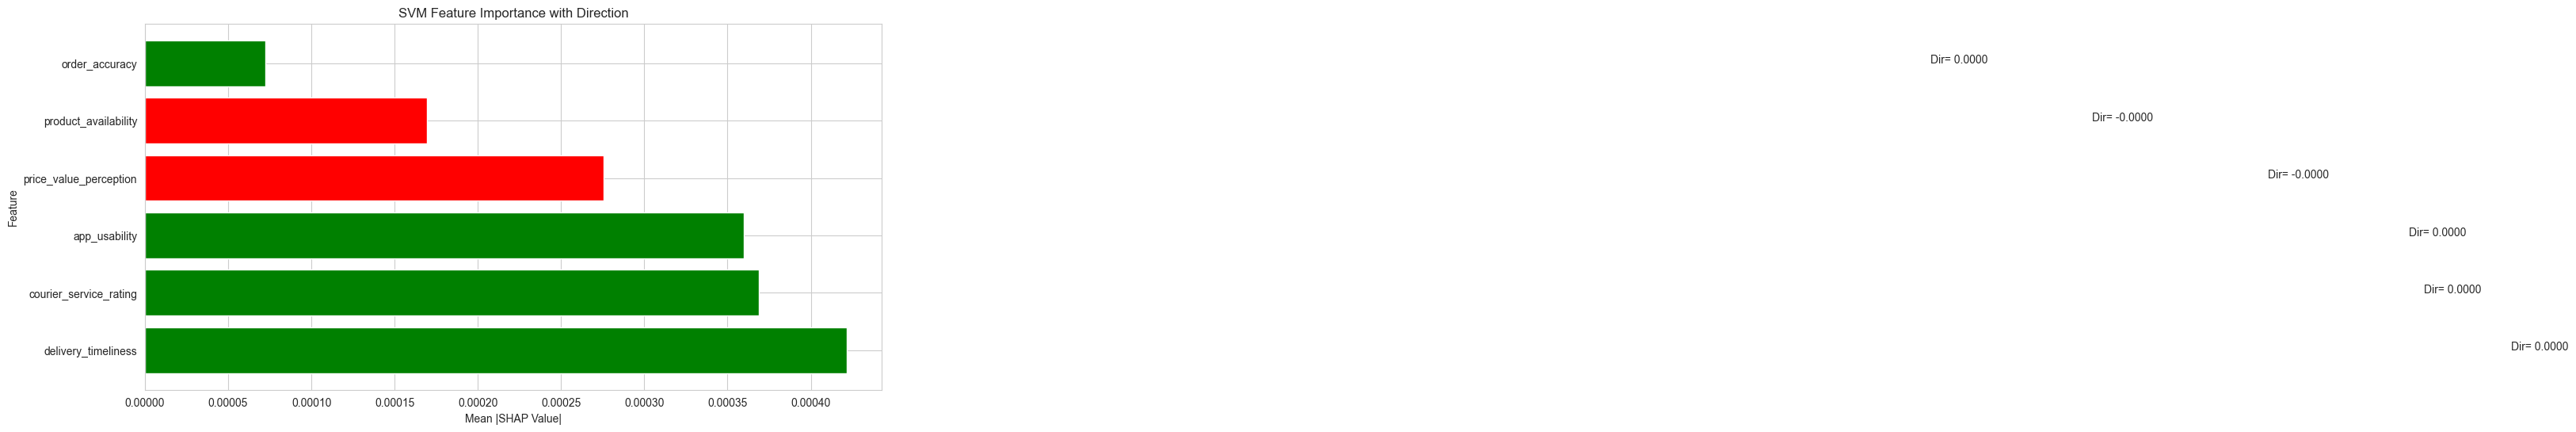

In [188]:
# Plot Mean Absolute SHAP importance per feature

# Sort by importance
plot_df = svm_shap_importance_df.sort_values(
    by='SVM_Mean_SHAP_Importance',
    ascending=True
)

# Create color based on direction
colors = [
    'green' if d > 0 else 'red'
    for d in svm_shap_importance_df['SVM_Mean_SHAP_Direction']
]

plt.figure(figsize=(12, 6))

plt.barh(
    svm_shap_importance_df['Feature'],
    svm_shap_importance_df['SVM_Mean_SHAP_Importance'],
    color=colors
)

plt.title('SVM Feature Importance with Direction')
plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')

for i, row in enumerate(svm_shap_importance_df.itertuples()):
    plt.text(
        row.SVM_Mean_SHAP_Importance + 0.001,
        i,
        f"Dir= {row.SVM_Mean_SHAP_Direction:.4f}"
    )

plt.tight_layout()
plt.show()

## 9.5. Compare the SHAP feature importance.

### 9.5.1. Most important feature.

In [189]:
# Print results
# Most important features and their importance values for each model.
print("Logistic Regression:")
print(lr_most_important_feature['Feature'])
print("Importance:", lr_most_important_feature['LR_Mean_SHAP_Importance'])

print("\nRandom Forest:")
print(rf_most_important_feature['Feature'])
print("Importance:", rf_most_important_feature['RF_Mean_SHAP_Importance'])

print("\nKNN:")
print(knn_most_important_feature['Feature'])
print("Importance:", knn_most_important_feature['KNN_Mean_SHAP_Importance'])

print("\nSVM:")
print(svm_most_important_feature['Feature'])
print("Importance:", svm_most_important_feature['SVM_Mean_SHAP_Importance'])

Logistic Regression:
order_accuracy
Importance: 0.19865334169281296

Random Forest:
delivery_timeliness
Importance: 0.07111206349247369

KNN:
order_accuracy
Importance: 0.057687037037037106

SVM:
delivery_timeliness
Importance: 0.00042142800106314334


### 9.5.2. Least important feature.

In [190]:
# Print results
# Least important feature and their importance values for each model.
print("Logistic Regression:")
print(lr_least_important_feature['Feature'])
print("Importance:", lr_least_important_feature['LR_Mean_SHAP_Importance'])

print("\nRandom Forest:")
print(rf_least_important_feature['Feature'])
print("Importance:", rf_least_important_feature['RF_Mean_SHAP_Importance'])

print("\nKNN:")
print(knn_least_important_feature['Feature'])
print("Importance:", knn_least_important_feature['KNN_Mean_SHAP_Importance'])

print("\nSVM:")
print(svm_least_important_feature['Feature'])
print("Importance:", svm_least_important_feature['SVM_Mean_SHAP_Importance'])

Logistic Regression:
product_availability
Importance: 0.08829195232757779

Random Forest:
product_availability
Importance: 0.013796070514647912

KNN:
app_usability
Importance: 5.7671957671949416e-05

SVM:
order_accuracy
Importance: 7.260653087504037e-05


# 10. Hyperparameter tuning with all possible subset of features to find most accurate model.

In [191]:
# Evaluate feature subsets using the model
from itertools import combinations

def evaluate_features(data, grid, target='customer_happiness'):
    feature_sets = []
    for r in range(1, len(X)):
        feature_combinations = combinations(X, r)
        for features in feature_combinations:
            feature_sets.append(list(features))

    accuracies = {}        

    for features in feature_sets:
        X_cv = data[features]
        y_cv = data[target]        

        X_cv_train, X_cv_test, y_cv_train, y_cv_test = train_test_split(
            X_cv, y_cv,
            test_size=0.2,
            random_state=4,
            stratify=y_cv
        )

        # Fit and predict using the Pipeline object
        grid.fit(X_cv_train, y_cv_train)
        y_cv_pred = grid.predict(X_cv_test)
        accuracy = accuracy_score(y_cv_test, y_cv_pred)
        accuracies[tuple(features)] = accuracy

    max_accuracy = max(accuracies.values())
    best_features = [list(feature) for feature, accuracy in accuracies.items() 
                     if accuracy == max_accuracy]

    return accuracies, best_features, max_accuracy

## 10.1. Logistic Regression hyperparameter tuning.

In [192]:
# C - regularization strength
# penalty - l1 or l2
# solver - algorithm to use in the optimization problem
# cv - number of cross-validation splits

# Create the Pipeline object
lr_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression())
])

lr_params_grid = {
    'lr__C':[0.001,0.01,0.1,1,10,100],
    'lr__penalty':['l1','l2'],
    'lr__solver':['liblinear']
}

grid = GridSearchCV(
    lr_pipeline,
    lr_params_grid,
    cv=5,
    scoring='accuracy'
)

accuracies, best_features, max_accuracy = evaluate_features(data, grid)
print("Best Feature Sets and Accuracy:")
for features, accuracy in accuracies.items():
    print("Feature Set:", features)
    print("Hyperparameters:", grid.best_params_)
    print("Accuracy:", accuracy)
    print()

Best Feature Sets and Accuracy:
Feature Set: ('delivery_timeliness',)
Hyperparameters: {'lr__C': 0.001, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Accuracy: 0.7692307692307693

Feature Set: ('order_accuracy',)
Hyperparameters: {'lr__C': 0.001, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Accuracy: 0.46153846153846156

Feature Set: ('product_availability',)
Hyperparameters: {'lr__C': 0.001, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Accuracy: 0.6153846153846154

Feature Set: ('price_value_perception',)
Hyperparameters: {'lr__C': 0.001, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Accuracy: 0.5

Feature Set: ('courier_service_rating',)
Hyperparameters: {'lr__C': 0.001, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Accuracy: 0.6538461538461539

Feature Set: ('app_usability',)
Hyperparameters: {'lr__C': 0.001, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Accuracy: 0.5769230769230769

Feature Set: ('delivery_timeliness', 'order_accuracy')
Hyperparameters: {'lr__C': 0.00

In [193]:
for features in best_features:
    print("Feature Set:", features)
    print("Hyperparameters:", grid.best_params_)
    print("Highest Accuracy:", max_accuracy)
    print()

Feature Set: ['delivery_timeliness']
Hyperparameters: {'lr__C': 0.001, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Highest Accuracy: 0.7692307692307693



## 10.2. Random Forest hyperparameter tuning.

In [194]:
# n_estimators - number of trees in the forest
# max_depth - maximum depth of the tree
# min_samples_leaf - minimum number of samples required to be at a leaf node
# cv - number of cross-validation splits

# Create the Pipeline object
rf_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("rf", RandomForestClassifier())
])

rf_param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [2, 3],
    'rf__min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    scoring='accuracy',
    cv=3
)

accuracies, best_features, max_accuracy = evaluate_features(data, grid)
print("Best Feature Sets and Accuracy:")
for features, accuracy in accuracies.items():
    print("Feature Set:", features)
    print("Hyperparameters:", grid.best_params_)
    print("Accuracy:", accuracy)
    print()

Best Feature Sets and Accuracy:
Feature Set: ('delivery_timeliness',)
Hyperparameters: {'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Accuracy: 0.7692307692307693

Feature Set: ('order_accuracy',)
Hyperparameters: {'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Accuracy: 0.5

Feature Set: ('product_availability',)
Hyperparameters: {'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Accuracy: 0.5384615384615384

Feature Set: ('price_value_perception',)
Hyperparameters: {'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Accuracy: 0.5384615384615384

Feature Set: ('courier_service_rating',)
Hyperparameters: {'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Accuracy: 0.5769230769230769

Feature Set: ('app_usability',)
Hyperparameters: {'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Accuracy: 0.5769230769230769

Feature Set: ('delivery_timeliness', 'order_a

In [195]:
for features in best_features:
    print("Feature Set:", features)
    print("Hyperparameters:", grid.best_params_)
    print("Highest Accuracy:", max_accuracy)
    print()

Feature Set: ['delivery_timeliness']
Hyperparameters: {'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Highest Accuracy: 0.7692307692307693

Feature Set: ['delivery_timeliness', 'courier_service_rating']
Hyperparameters: {'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Highest Accuracy: 0.7692307692307693



## 10.3. KNN hyperparameter tuning.

In [196]:
# n_neighbors - number of neighbors to use
# weights - weight function used in prediction
# cv - number of cross-validation splits

knn_param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

# Create the Pipeline object
knn_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    scoring='accuracy',
    cv=5
)

accuracies, best_features, max_accuracy = evaluate_features(data, grid)
print("Best Feature Sets and Accuracy:")
for features, accuracy in accuracies.items():
    print("Feature Set:", features)
    print("Hyperparameters:", grid.best_params_)
    print("Accuracy:", accuracy)
    print()

Best Feature Sets and Accuracy:
Feature Set: ('delivery_timeliness',)
Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Accuracy: 0.6923076923076923

Feature Set: ('order_accuracy',)
Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Accuracy: 0.5

Feature Set: ('product_availability',)
Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Accuracy: 0.5384615384615384

Feature Set: ('price_value_perception',)
Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Accuracy: 0.5

Feature Set: ('courier_service_rating',)
Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Accuracy: 0.5769230769230769

Feature Set: ('app_usability',)
Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Accuracy: 0.5769230769230769

Feature Set: ('del

In [197]:
for features in best_features:
    print("Feature Set:", features)
    print("Hyperparameters:", grid.best_params_)
    print("Highest Accuracy:", max_accuracy)
    print()

Feature Set: ['delivery_timeliness', 'product_availability', 'app_usability']
Hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Highest Accuracy: 0.8461538461538461



## 10.4. SVM hyperparameter tuning.

In [198]:
# C - regularization strength
# kernel - kernel type
# gamma - kernel coefficient
# cv - number of cross-validation splits

# Create the Pipeline object
svm_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("svm", SVC(probability=True))
])

svm_param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    scoring='accuracy',
    cv=5
)

accuracies, best_features, max_accuracy = evaluate_features(data, grid)
print("Best Feature Sets and Accuracy:")
for features, accuracy in accuracies.items():
    print("Feature Set:", features)
    print("Hyperparameters:", grid.best_params_)
    print("Accuracy:", accuracy)
    print()

Best Feature Sets and Accuracy:
Feature Set: ('delivery_timeliness',)
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Accuracy: 0.7692307692307693

Feature Set: ('order_accuracy',)
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Accuracy: 0.5384615384615384

Feature Set: ('product_availability',)
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Accuracy: 0.5384615384615384

Feature Set: ('price_value_perception',)
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Accuracy: 0.5384615384615384

Feature Set: ('courier_service_rating',)
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Accuracy: 0.5769230769230769

Feature Set: ('app_usability',)
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Accuracy: 0.5384615384615384

Feature Set: ('delivery_timeliness', 'order_accuracy')
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale',

In [199]:
for features in best_features:
    print("Feature Set:", features)
    print("Hyperparameters:", grid.best_params_)
    print("Highest Accuracy:", max_accuracy)
    print()

Feature Set: ['delivery_timeliness', 'product_availability']
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Highest Accuracy: 0.8076923076923077

Feature Set: ['delivery_timeliness', 'product_availability', 'courier_service_rating', 'app_usability']
Hyperparameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Highest Accuracy: 0.8076923076923077

